# Regressão Linear com PyTorch - Dataset Salary Data

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/harlfoxem/housesalesprediction).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [526]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [527]:
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/franciscadias/data/master/kc_house_data.csv')

X = df[['sqft_living', 'bedrooms', 'bathrooms', 'grade', 'yr_built', 'sqft_lot',	'floors',	'waterfront',	'view',	'condition',	'grade',	'sqft_above',	'sqft_basement',	'yr_renovated',	'lat',	'long',	'sqft_living15']].values
y = df[['price']].values

In [528]:
df.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Normalização dos dados

In [529]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [530]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 17])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 17])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

In [531]:
model = torch.nn.Linear(17, 1)

### Verificando a inicialização dos parâmetros

In [532]:
model.weight.data

tensor([[-0.2285, -0.0476, -0.1165, -0.0647, -0.2143,  0.0973, -0.2174, -0.0155,
          0.0843, -0.0818,  0.1376,  0.0306,  0.1333,  0.1556, -0.1071,  0.0881,
         -0.1049]])

### Testando o predict da rede

In [533]:
model(torch.ones(5,17))

tensor([[-0.3952],
        [-0.3952],
        [-0.3952],
        [-0.3952],
        [-0.3952]], grad_fn=<AddmmBackward0>)

In [534]:
model(X_train_tensor[:3])

tensor([[-0.6648],
        [ 0.4515],
        [-0.2587]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [535]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
num_epochs = 500

### Laço de treinamento

In [536]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value

In [537]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

In [538]:
w0_list = []
w1_list = []
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # Store weights and biases for plotting later (w0 -> weight, w1 -> bias)
    w0_list.append(model.weight.data[0][0].item())
    if model.bias is not None:
        w1_list.append(model.bias.data[0].item())
    else:
        w1_list.append(0.0) # Append 0 if no bias

    # verbose
    if (epoch + 1) % 20 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[20/500], Train Loss: 0.297685, Val Loss: 0.329749
Epoch[40/500], Train Loss: 0.295692, Val Loss: 0.327743
Epoch[60/500], Train Loss: 0.295531, Val Loss: 0.327702
Epoch[80/500], Train Loss: 0.295512, Val Loss: 0.327743
Epoch[100/500], Train Loss: 0.295509, Val Loss: 0.327768
Epoch[120/500], Train Loss: 0.295509, Val Loss: 0.327779
Epoch[140/500], Train Loss: 0.295509, Val Loss: 0.327784
Epoch[160/500], Train Loss: 0.295509, Val Loss: 0.327786
Epoch[180/500], Train Loss: 0.295509, Val Loss: 0.327787
Epoch[200/500], Train Loss: 0.295509, Val Loss: 0.327787
Epoch[220/500], Train Loss: 0.295509, Val Loss: 0.327788
Epoch[240/500], Train Loss: 0.295509, Val Loss: 0.327788
Epoch[260/500], Train Loss: 0.295509, Val Loss: 0.327788
Epoch[280/500], Train Loss: 0.295509, Val Loss: 0.327788
Epoch[300/500], Train Loss: 0.295509, Val Loss: 0.327788
Epoch[320/500], Train Loss: 0.295509, Val Loss: 0.327788
Epoch[340/500], Train Loss: 0.295509, Val Loss: 0.327788
Epoch[360/500], Train Loss: 0.29550

## Avaliação

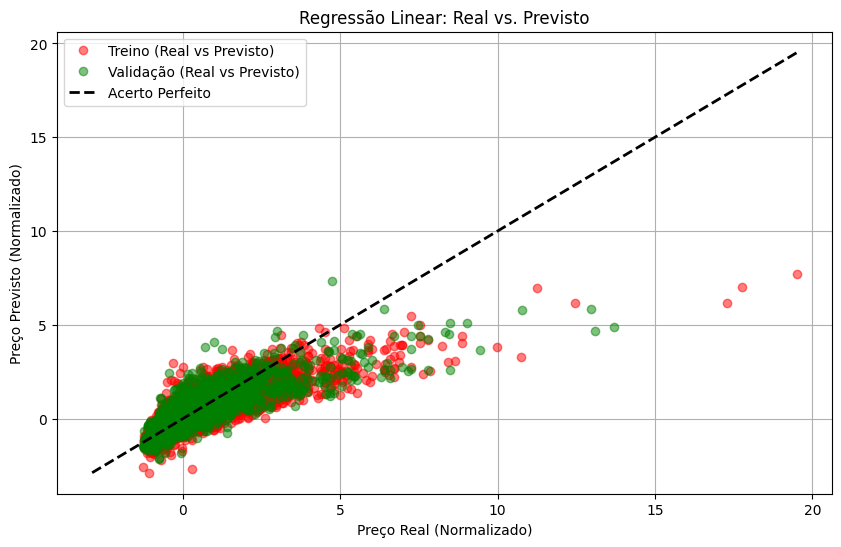

In [539]:
y_pred_train = model(X_train_tensor).detach()
y_pred_val = model(X_val_tensor).detach()

plt.figure(figsize=(10, 6))

# Plot treino: Preço Real (X) vs Preço Previsto (Y)
plt.plot(y_train_tensor.numpy(), y_pred_train.numpy(), 'ro', alpha=0.5, label='Treino (Real vs Previsto)')

# Plot validação: Preço Real (X) vs Preço Previsto (Y)
plt.plot(y_val_tensor.numpy(), y_pred_val.numpy(), 'go', alpha=0.5, label='Validação (Real vs Previsto)')

# Linha de perfeição
min_val = min(y_train_tensor.min().item(), y_pred_train.min().item())
max_val = max(y_train_tensor.max().item(), y_pred_train.max().item())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Acerto Perfeito')

plt.xlabel('Preço Real (Normalizado)')
plt.ylabel('Preço Previsto (Normalizado)')
plt.title('Regressão Linear: Real vs. Previsto')
plt.legend()
plt.grid(True)
plt.show()

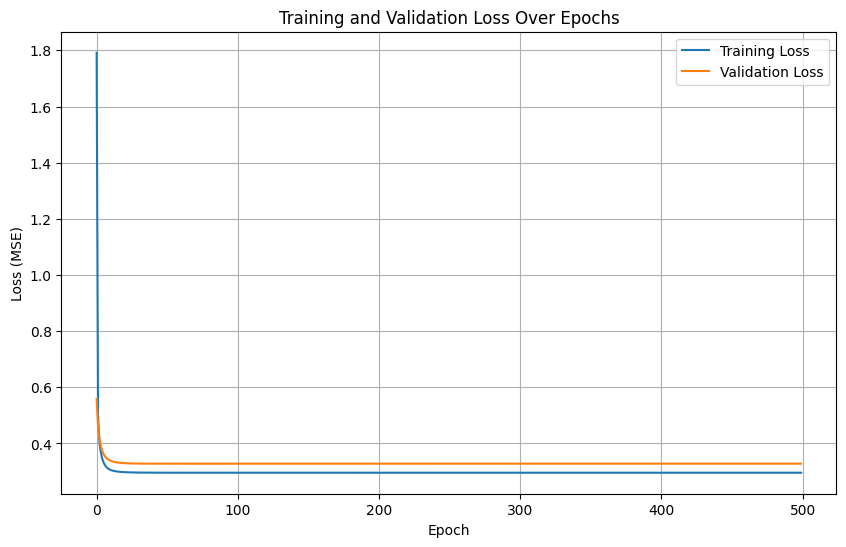

In [540]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [541]:
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Extrair os valores previstos e remover do grafo de gradiente (.detach)
y_pred_val_np = model(X_val_tensor).detach().numpy()
y_val_np = y_val_tensor.numpy()

# 2. Desfazer a normalização para voltar para a escala de Dólares
y_val_real = y_scaler.inverse_transform(y_val_np)
y_pred_real = y_scaler.inverse_transform(y_pred_val_np)

# 3. Calcular as métricas reais
mae = mean_absolute_error(y_val_real, y_pred_real)
r2 = r2_score(y_val_real, y_pred_real)

print(f"Erro Médio Absoluto (MAE): US$ {mae:,.2f}")
print(f"R² (Taxa de Explicação/Predição): {r2:.4f} (ou {r2*100:.2f}%)")

Erro Médio Absoluto (MAE): US$ 128,064.49
R² (Taxa de Explicação/Predição): 0.6940 (ou 69.40%)
